In [1]:
import numpy as np
import matplotlib as py
import scipy.spatial as sc
import matplotlib.pyplot as plt
import time
import traceback
#from numba import njit

In [2]:
X = np.zeros((6,3))

In [3]:
D = sc.distance.pdist(X)

In [4]:


def round(x, base=1):
    return base * np.round(x/base)

def roundInt(x):
    return np.round(x).astype(np.int)


def computeAllDistance(X):
    return sc.distance.pdist(X)

def computeAllDistanceInPlane(X):
    return sc.distance.pdist(X[:,0:2])

def getDistance(D,k,j):
    if k<j:
        l = len(X) * k + j - ((k + 2) * (k + 1)) // 2
    if k>j:
        l = len(X) * j + k - ((j + 2) * (j + 1)) // 2
    return D[l]

def getAllDistance(D,k,L):
    j1 = np.arange(0,k)
    j2 = np.arange(k+1,L)
    l1 = L * j1 + k - ((j1 + 2) * (j1 + 1)) // 2
    l2 = L * k + j2 - ((k + 2) * (k + 1)) // 2
    l = np.hstack((l1,l2))
    return(D[l])


def cartesianToSpherical(X,rp = None,rs = None):
    Xs = np.zeros(X.shape)
    if rp == None:
        rp = X[:,0]**2 + X[:,1]**2
    if rs == None:
        rs = np.sqrt(rp + X[:,2]**2)
    Xs[:,0] = rs
    #ptsnew[:,4] = np.arctan2(np.sqrt(xy), xyz[:,2]) # for elevation angle defined from Z-axis down
    Xs[:,2] = np.arctan2(X[:,2], np.sqrt(rp)) # for elevation angle defined from XY-plane up
    Xs[:,1] = np.arctan2(X[:,1], X[:,0])
    return Xs

def drawSphere(Xs,R,size):
    dPhi = 2*np.pi/(size[0]-1)
    dTheta = np.pi/(size[1]-1)
    theta0 = Xs[2]
    phi0 = Xs[1]
    
    #i don't know what approximation to use
    #thetaApp = np.arcsin(R/Xs[0])
    thetaApp = np.arctan2(R,Xs[0])
    thetaMin = round(theta0-thetaApp,dTheta)
    thetaMax = round(theta0+thetaApp,dTheta)
    thetaN = 1+roundInt((thetaMax-thetaMin)/dTheta)

    if thetaN == 1:
        thetaIdx = np.floor(size[1]/2) + np.round(((theta0/dTheta)))

        phiIdx = np.floor(size[0]/2) + round(phi0 / dPhi)
        vIdx = np.array([phiIdx,thetaIdx])
    else:
        theta = np.linspace(thetaMin,thetaMax,thetaN)
        
        thetaSpace = theta - round(theta0,dTheta)

        theta[theta > np.pi/2.0] = np.pi - theta[theta > np.pi/2.0]
        theta[theta < -np.pi/2.0] = - np.pi - theta[theta < -np.pi/2.0]

        thetaIdx = np.floor(size[1]/2) + np.round(((theta/dTheta)))

        ## no idea where this 2 or the 4 is coming from
        phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))

        thetaIdx = thetaIdx[~np.isnan(phiLim)]

        phiLim = phiLim[~np.isnan(phiLim)]
        phiMax =  (np.floor(size[0]/2) + round((phi0 + phiLim) / dPhi))
        phiMin =  (np.floor(size[0]/2) + round((phi0 - phiLim) / dPhi))

        idx = []
        for thetaIdx,phiIdxMin,phiIdxMax in zip(thetaIdx,phiMin,phiMax):

            if phiIdxMax-phiIdxMin >size[0] or phiIdxMax == -2147483648:
                phiIdx = np.arange(0,size[0])


            else:
                phiIdx = np.arange(phiIdxMin,phiIdxMax+1)%size[0]

            idxLine = np.vstack([phiIdx,thetaIdx*np.ones(len(phiIdx))]).T
            idx.append(idxLine)
        vIdx = np.concatenate(idx)
    return roundInt(vIdx)


def computeVisualField(X,R,size):
    Xs = cartesianToSpherical(X)
    for k in range(0,np.shape(X)[0]):
        try:
            vIdxTmp = drawSphere(Xs[k,:],R,size)
        except:
            print(Xs[k,:])
        try:
            vIdx = np.vstack([vIdx,vIdxTmp])
        except:
            vIdx = vIdxTmp
    V = np.zeros([size[1],size[0]])
    try:
        V[vIdx[:,1],vIdx[:,0]] = 1
    except:
        V[vIdx[1],vIdx[0]] = 1
        
    return V



In [5]:
size = 8
size = [2*size+1,size+1]
vIdx = drawSphere([5, 0, 0],1,size)
V = np.zeros([size[1],size[0]])
print(vIdx)
try:
    V[vIdx[:,1],vIdx[:,0]] = 1
except:
    print(vIdx)
    V[vIdx[1],vIdx[0]] = 1
V

[[7 4]
 [8 4]
 [9 4]]


<ipython-input-4-696c1fd9033c>:71: RuntimeWarning: invalid value encountered in sqrt
  phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.]])

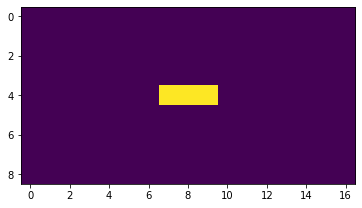

In [6]:
plt.imshow(V)

In [7]:

nxx = [2]#roundInt(np.linspace(1,100,10))
t=[]
x= (.5-np.random.rand(100,3))*4
for nx in nxx:
    print(nx)
    size = [2*nx+1,nx+1]
    t0 = time.time()

    vIdx = computeVisualField(x,1,size)
    t.append(time.time()-t0)

2


<ipython-input-4-696c1fd9033c>:71: RuntimeWarning: invalid value encountered in sqrt
  phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))


In [8]:
3%3

0

In [9]:
size = 1
size = [2*1+1,1+1]
vIdx = drawSphere([5, 0, 0],1,size)
V = np.zeros([size[1],size[0]])
print(vIdx)
try:
    V[vIdx[:,1],vIdx[:,0]] = 1
except:
    print(vIdx)
    V[vIdx[1],vIdx[0]] = 1
V

[1 1]
[1 1]


array([[0., 0., 0.],
       [0., 1., 0.]])

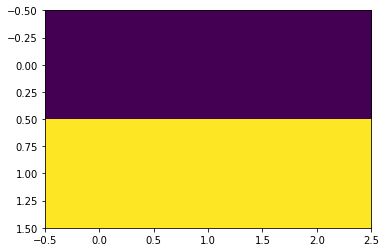

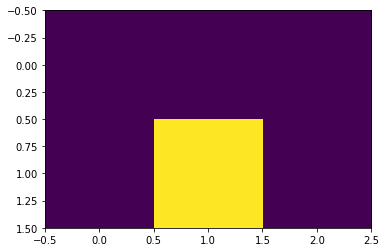

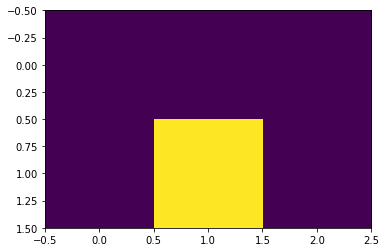

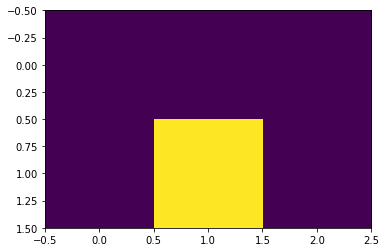

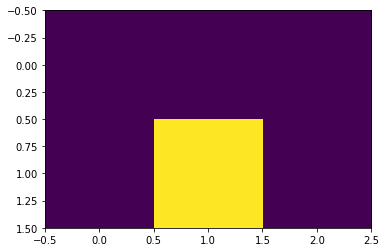

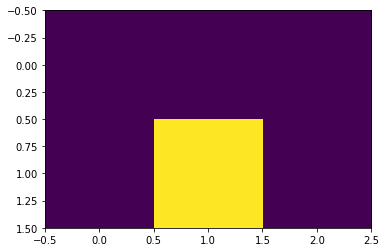

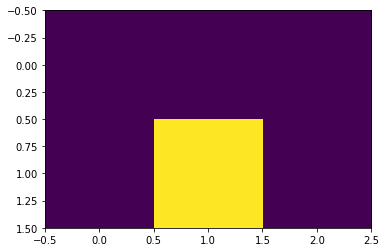

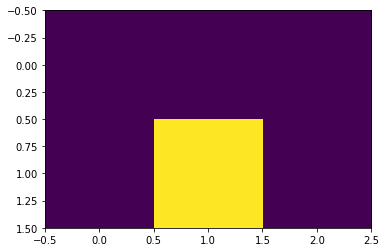

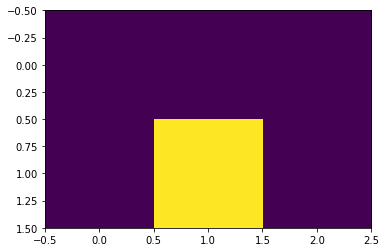

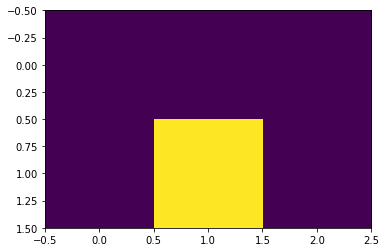

In [10]:

x= (.5-np.random.rand(100,3))*40
for k in range(0,10):
    plt.figure()
    plt.imshow(computeVisualField(x+k*1000,1,size))

In [11]:
V = np.zeros([size[1],size[0]])
V[tmp[:,1],tmp[:,0]] = 1

NameError: name 'tmp' is not defined

In [ ]:
plt.imshow(V)

In [ ]:
for k in np.linspace(-np.pi/2.0,np.pi/2.0,10):
    tmp = drawSphere(
        [5,0,k],1,size)
    plt.figure()
    V = np.zeros([size[1],size[0]])
    V[tmp[:,1],tmp[:,0]] = 1
    plt.imshow(V)

In [ ]:
plt.plot(tmp[:,0],tmp[:,1])

In [ ]:
print(theta/dTheta)
print(np.round(theta/dTheta).astype(np.int))

In [ ]:
np.arange(-1,2)

In [ ]:
nTheta=5
thetaMin = np.pi/4
thetaMax = 3*np.pi/4
theta = np.linspace(thetaMin,thetaMax,thetaN)
plt.plot(theta)

theta[theta > np.pi/2.0] = np.pi - theta[theta > np.pi/2.0]
theta[theta < -np.pi/2.0] = - np.pi - theta[theta < -np.pi/2.0]
plt.plot(theta)

In [ ]:
x= np.random.rand(10,3)*10

In [ ]:
import time

nxx = roundInt(np.linspace(1,1000,100))
t=[]
for nx in nxx:
    x= (.5-np.random.rand(nx,3))*40
    t0 = time.time()
    
    computeVisualField(x,1,size)
    t.append(time.time()-t0)

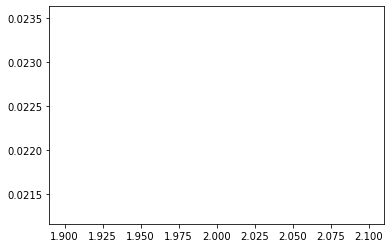

In [12]:
plt.plot(nxx,t)

In [13]:
import time

nxx = roundInt(np.linspace(1,100,10))
t=[]
x= (.5-np.random.rand(100,3))*4
for nx in nxx:
    size = [2*nx+1,nx+1]
    t0 = time.time()

    computeVisualField(x,1,size)
    t.append(time.time()-t0)

<ipython-input-4-696c1fd9033c>:71: RuntimeWarning: invalid value encountered in sqrt
  phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))


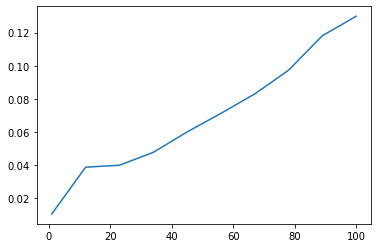

In [14]:
plt.plot(nxx,t)

2
112
224
334
446
556
668
778
890


<ipython-input-4-696c1fd9033c>:71: RuntimeWarning: invalid value encountered in sqrt
  phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))


1000


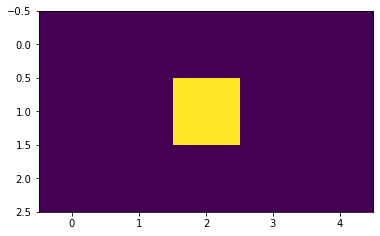

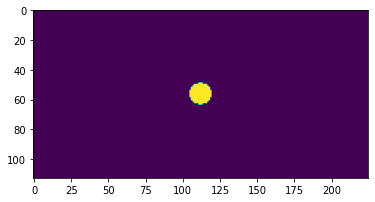

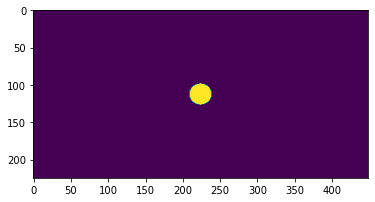

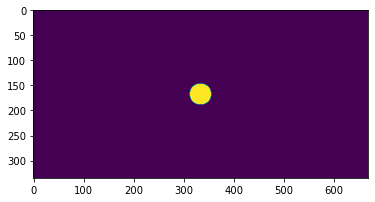

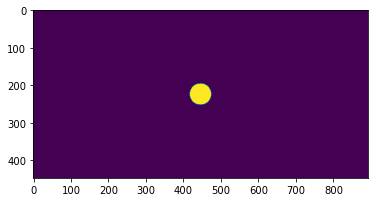

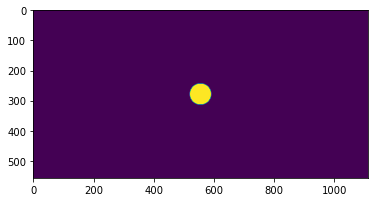

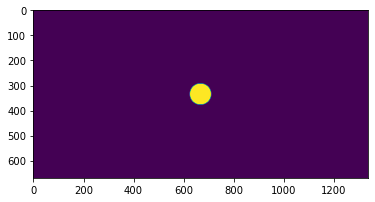

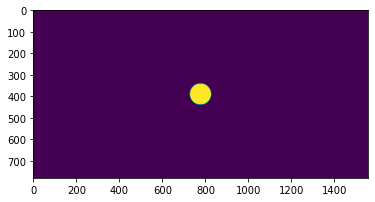

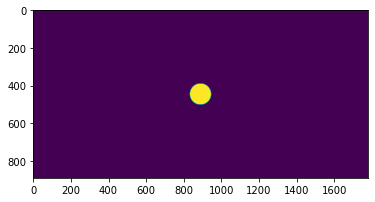

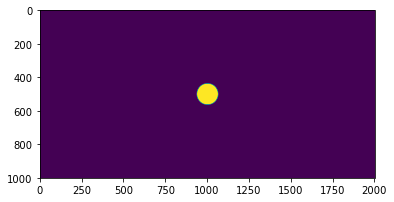

In [15]:

x= np.zeros((1,3))
x[0,:] = [5,0,0]
nxx = roundInt(np.linspace(1,500,10))*2
for nx in nxx:
    print(nx)
    size = [2*nx+1,nx+1]
    plt.figure()
    V = computeVisualField(x,1,size)
    plt.imshow(V)

In [16]:
np.shape(x)

(1, 3)

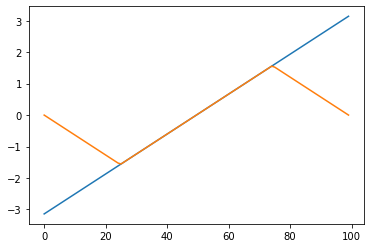

In [17]:
nTheta=5
thetaMin = -np.pi
thetaMax = np.pi
theta = np.linspace(thetaMin,thetaMax,100)
plt.plot(theta)

theta[theta > np.pi/2.0] = np.pi - theta[theta > np.pi/2.0]
theta[theta < -np.pi/2.0] = - np.pi - theta[theta < -np.pi/2.0]
plt.plot(theta)

In [18]:
theta = np.linspace(thetaMin,thetaMax,100)

In [19]:
theta

array([-3.14159265, -3.07812614, -3.01465962, -2.9511931 , -2.88772658,
       -2.82426006, -2.76079354, -2.69732703, -2.63386051, -2.57039399,
       -2.50692747, -2.44346095, -2.37999443, -2.31652792, -2.2530614 ,
       -2.18959488, -2.12612836, -2.06266184, -1.99919533, -1.93572881,
       -1.87226229, -1.80879577, -1.74532925, -1.68186273, -1.61839622,
       -1.5549297 , -1.49146318, -1.42799666, -1.36453014, -1.30106362,
       -1.23759711, -1.17413059, -1.11066407, -1.04719755, -0.98373103,
       -0.92026451, -0.856798  , -0.79333148, -0.72986496, -0.66639844,
       -0.60293192, -0.53946541, -0.47599889, -0.41253237, -0.34906585,
       -0.28559933, -0.22213281, -0.1586663 , -0.09519978, -0.03173326,
        0.03173326,  0.09519978,  0.1586663 ,  0.22213281,  0.28559933,
        0.34906585,  0.41253237,  0.47599889,  0.53946541,  0.60293192,
        0.66639844,  0.72986496,  0.79333148,  0.856798  ,  0.92026451,
        0.98373103,  1.04719755,  1.11066407,  1.17413059,  1.23